In [2]:
# %%
import numpy as np
from matplotlib import pyplot as plt
import csv

# %matplotlib inline

import xarray as xr
import lib_ecofun as lef
from importlib import reload
reload(lef)
from scipy.optimize import curve_fit, minimize, dual_annealing, basinhopping, brute, differential_evolution, shgo, direct

# %%
lef.beta_fun(0, 1, delta_sig= 0.5)

# %% [markdown]
# # Model tuning

# %% [markdown]
# ### Setting inicond and obs to fit

# %%
fcu = 0.8
inicond = lef.inicond_yr(2000)
# inicond['Kf_ini'] = inicond['Kf_ini']*lef.fossil_capacity_util/fcu

obs = dict()
obs['Ig_ratio'] = lef.Ig_obs/(lef.Ig_obs+lef.If_obs) # considering only investment in power generation capacity (no grids, storage, EVs, ...)
obs['Eg_ratio'] = lef.Eg_ratio_fe

# E_obs = xr.load_dataarray('Etot_hist_1965-2022.nc')
# E_obs /= E_obs.sel(year = 2000)
obs['E'] = lef.final_energy

# %% [markdown]
# ### Chose params to fit and bounds (initial guess only needed for minimize)

# %%
parnames = ['growth', 'beta_0', 'r_inv', 'a', 'b', 'eta_g', 'eta_f']
bounds = [(0.01, 0.03), (-0.5, 0.5), (0.2, 0.8), (0.5, 1.5), (0.5, 1.5), (0.2, 0.9), (0.2, 0.9)]

initial_guess = [lef.best_params[par] for par in parnames]

param_bounds = {par: boun for par, boun in zip(parnames, bounds)}

# %%
year_ini = 2000

params = lef.default_params.copy()
print(params)
print('-------------')
params['delta_sig'] = 0.5
# params['eta_g'] = 0.8
# params['eta_f'] =
#params['growth'] = 0.029 # fixing Growth!

verbose = False

public_investment = False

params['r_inv_state'] = 0.015
arr = np.concatenate([np.linspace(0., 0.7, 20), np.linspace(0.7, 0.7, 80)])
mu_scen = xr.DataArray(arr, dims = ('year'), coords = {'year': np.arange(year_ini, 2100)})

obs_weights = None

result_dict = {}

{'growth': 0.01, 'eps': 1, 'a': 1, 'b': 1, 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.1, 'beta_0': 0.2, 'delta_sig': 0.5, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.01}
-------------


In [2]:
result = dual_annealing(lef.cost_function, bounds, args = (parnames, params, year_ini, inicond, verbose, obs, public_investment, mu_scen, obs_weights))
print(f'AAAAAAAAAAAAAAA dual: {result.fun:5.2f}  ', result.x)
result_dict['dual'] = result

---------------------
{'growth': np.float64(0.028575353888546894), 'beta_0': np.float64(0.21647749291098362), 'r_inv': np.float64(0.2521609757356339), 'a': np.float64(0.5665466781106175), 'b': np.float64(1.4657039277175739), 'eta_g': np.float64(0.48306497223391914), 'eta_f': np.float64(0.7384428059807426)}
---------------------
{'growth': np.float64(0.0241516666616039), 'beta_0': np.float64(0.4978533685207367), 'r_inv': np.float64(0.7335368629368106), 'a': np.float64(0.8479225486516953), 'b': np.float64(0.7612802386283875), 'eta_g': np.float64(0.6786412856404156), 'eta_f': np.float64(0.2340191184405656)}
Too short! extending up to 2025
---------------------
{'growth': np.float64(0.015223175662938548), 'beta_0': np.float64(0.4501955211162567), 'r_inv': np.float64(0.3646083836994423), 'a': np.float64(1.4789940640330315), 'b': np.float64(1.3923517540097237), 'eta_g': np.float64(0.5309834346411426), 'eta_f': np.float64(0.5650906239134135)}
Too short! extending up to 2025
------------------

In [3]:
result

 message: ['Maximum number of iteration reached']
 success: True
  status: 0
     fun: 0.043814953445750565
       x: [ 2.094e-02 -3.307e-01  2.000e-01  1.063e+00  1.230e+00
            2.704e-01  7.039e-01]
     nit: 1000
    nfev: 16281
    njev: 285
    nhev: 0

In [ ]:

result = differential_evolution(lef.cost_function, bounds, args = (parnames, params, year_ini, inicond, verbose, obs, public_investment, mu_scen, obs_weights))
print(f'AAAAAAAAAAAAAAA diffevo: {result.fun:5.2f}  ', result.x)
result_dict['de'] = result

In [ ]:
result = basinhopping(lef.cost_function, x0= initial_guess, minimizer_kwargs = {'args': (parnames, params, year_ini, inicond, verbose, obs, public_investment, mu_scen, obs_weights, param_bounds)}, niter = 1000)
print(f'AAAAAAAAAAAAAAA hopping: {result.fun:5.2f}  ', result.x)
result_dict['hop'] = result

In [5]:
from importlib import reload
reload(lef)

<module 'lib_ecofun' from '/home/fabiano/Research/git/ecodyn/lib_ecofun.py'>

In [6]:
costs_dict, params_all_dict = lef.read_costs_from_log('log_newfit_10nov_igratio.log')

In [9]:
costs_all, params_all = np.concatenate(costs_dict), np.concatenate(params_all_dict)

In [10]:
param_bounds = {'growth': (0.0, 0.05),
 'a': (0.1, 5),
 'b': (0.1, 5),
 'eta_g': (0.1, 0.9),
 'eta_f': (0.1, 0.9),
 'r_inv': (0.1, 0.9),
 'beta_0': (-0.5, 0.5)}

In [11]:
costs_all, params_all = lef.filter_by_bounds(costs_all, params_all, param_bounds)

In [ ]:
year_ini = 2000

resu_all = []
for parvals in params_all:
    resu_x = lef.run_model(inicond = inicond, params = params, n_iter = 100, verbose = False, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen)
    resu_all.append(resu_x)

In [13]:
len(resu_all)

3363

In [55]:
def scalars_to_colors(scalars, cmap='viridis'):
    """
    Convert list of scalars to colors from a colormap
    
    Args:
        scalars: list of scalar values
        cmap: colormap name (default 'viridis')
    
    Returns:
        colors: list of RGBA colors
    """
    # Normalize scalars to [0, 1]
    scalars = np.array(scalars)
    normalized = (scalars - np.nanmin(scalars)) / (np.nanmax(scalars) - np.nanmin(scalars))
    
    # Get colormap and convert to colors
    cmap = plt.get_cmap(cmap)
    colors = [cmap(val) if not np.isnan(val) else 'grey' for val in normalized]
    
    return colors

In [18]:
colors = scalars_to_colors(costs_all, cmap = 'viridis_r')
#colors = ['steelblue' if re.transition else 'orange' for re in resu_all]
#colors = ['steelblue']*len(costs_dict[0]) + ['orange']*len(costs_dict[1]) +['indianred']*len(costs_dict[2])

(array([176., 104.,   8.,   0., 257., 408., 306., 107.,  80.,  45.,  36.,
         20.,  21.,  25., 103.,  60.,  28.,  10., 277., 179., 106.,  32.,
         17.,  22.,  16., 116., 139.,  42.,  55.,  63.,  66.,  74.,  52.,
         49.,  59.,  53.,  37.,  53.,  31.,  31.]),
 array([0.04302499, 0.04319936, 0.04337373, 0.0435481 , 0.04372247,
        0.04389684, 0.04407121, 0.04424558, 0.04441995, 0.04459432,
        0.04476869, 0.04494306, 0.04511743, 0.0452918 , 0.04546617,
        0.04564054, 0.04581491, 0.04598928, 0.04616365, 0.04633802,
        0.04651239, 0.04668676, 0.04686113, 0.0470355 , 0.04720986,
        0.04738423, 0.0475586 , 0.04773297, 0.04790734, 0.04808171,
        0.04825608, 0.04843045, 0.04860482, 0.04877919, 0.04895356,
        0.04912793, 0.0493023 , 0.04947667, 0.04965104, 0.04982541,
        0.04999978]),
 <BarContainer object of 40 artists>)

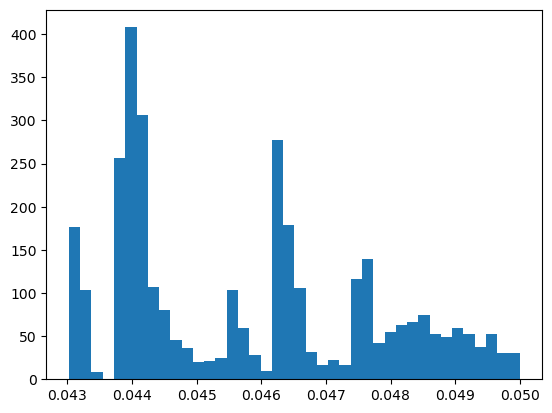

In [21]:
plt.hist(costs_all, bins = 40)

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

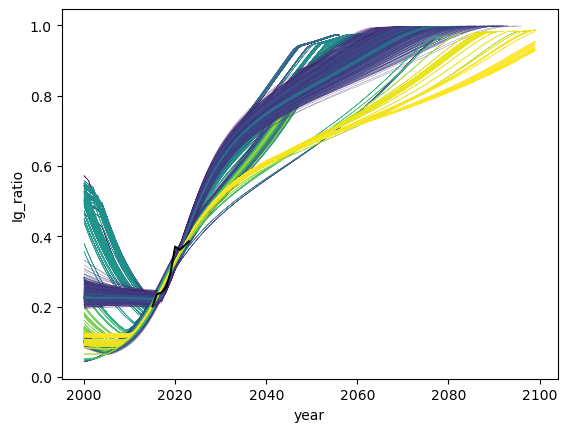

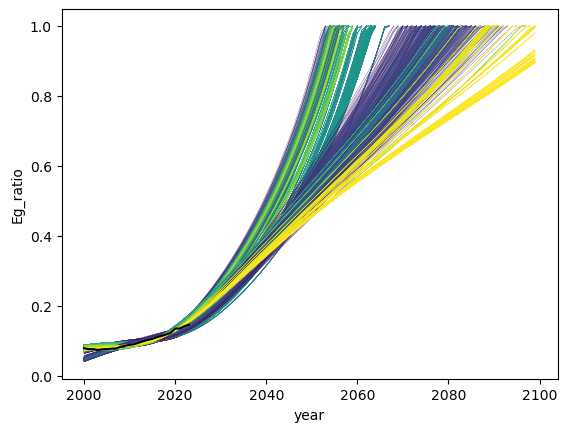

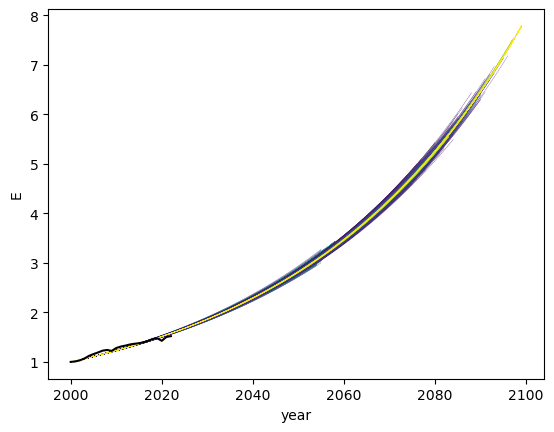

In [19]:
lef.plot_resuvsobs_ds(resu_all, obs, year_ok = slice(2000, 2100), greystyle=True, colors=colors)

In [40]:
cp = np.percentile(costs_all, 20)

In [41]:
resu_ok = [re for re,co in zip(resu_all, costs_all) if co < cp]

In [46]:
yearzero = [re.year_zero for re in resu_ok]

(array([219., 130.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   8.,   0.,
          0.,   0.,   0.,   8.,   8.,  40.,  32.,   8.,   0.,   8.,   0.,
          0.,   8.,   0.,   8.,   8.,  16.]),
 array([2055.  , 2055.88, 2056.76, 2057.64, 2058.52, 2059.4 , 2060.28,
        2061.16, 2062.04, 2062.92, 2063.8 , 2064.68, 2065.56, 2066.44,
        2067.32, 2068.2 , 2069.08, 2069.96, 2070.84, 2071.72, 2072.6 ,
        2073.48, 2074.36, 2075.24, 2076.12, 2077.  , 2077.88, 2078.76,
        2079.64, 2080.52, 2081.4 , 2082.28, 2083.16, 2084.04, 2084.92,
        2085.8 , 2086.68, 2087.56, 2088.44, 2089.32, 2090.2 , 2091.08,
        2091.96, 2092.84, 2093.72, 2094.6 , 2095.48, 2096.36, 2097.24,
        2098.12, 2099.  ]),
 <BarContainer object of 50 artists>)

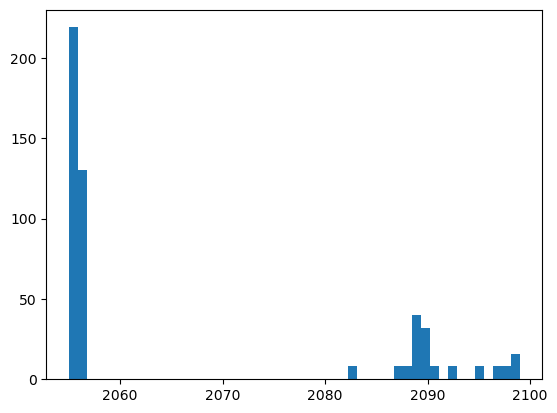

In [49]:
plt.hist(yearzero, bins = 50)

In [51]:
np.sum(np.array(yearzero) < 2060), len(yearzero)

(np.int64(349), 653)

In [60]:
#colors = scalars_to_colors(yearzero, cmap = 'viridis_r')
colors = ['forestgreen' if ye < 2060 else 'orange' for ye in yearzero]

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

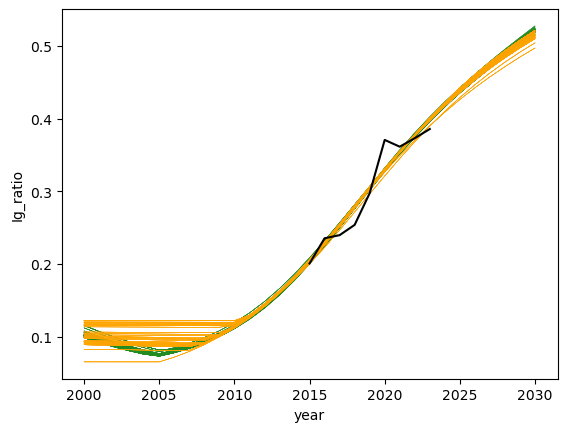

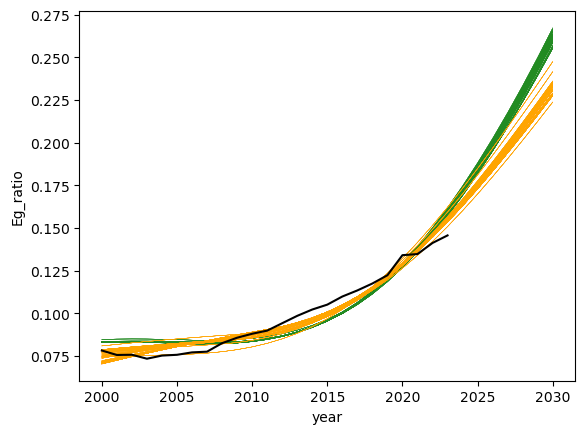

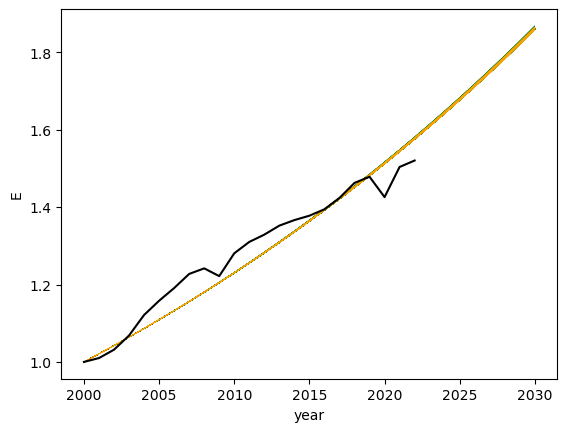

In [62]:
lef.plot_resuvsobs_ds(resu_ok, obs, year_ok = slice(2000, 2030), greystyle=True, colors = colors)

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

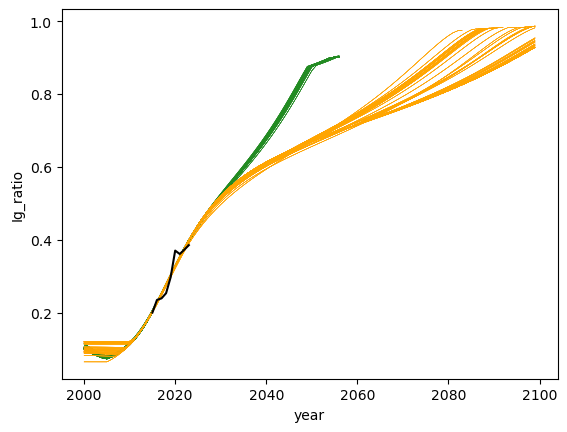

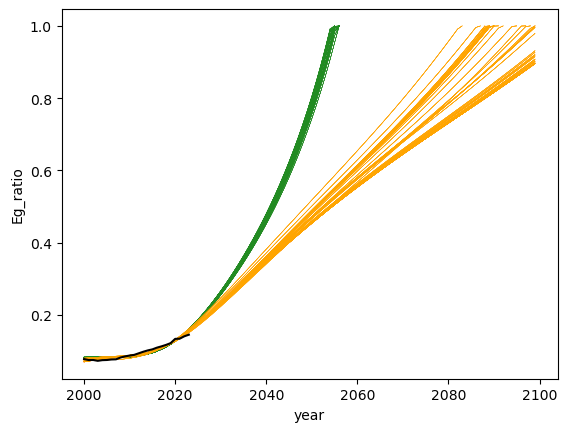

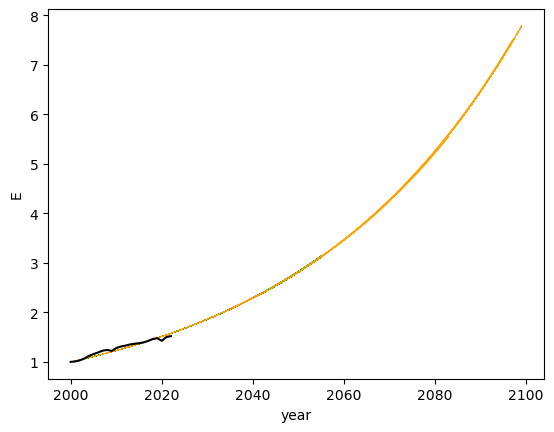

In [61]:
lef.plot_resuvsobs_ds(resu_ok, obs, year_ok = slice(2000, 2100), greystyle=True, colors = colors)

### With diffevo + sobol

In [4]:
import pickle

79


(array([36.,  9.,  1.,  0., 21.,  2.,  0.,  0.,  0., 10.]),
 array([0.04382373, 0.04386663, 0.04390952, 0.04395242, 0.04399532,
        0.04403822, 0.04408111, 0.04412401, 0.04416691, 0.0442098 ,
        0.0442527 ]),
 <BarContainer object of 10 artists>)

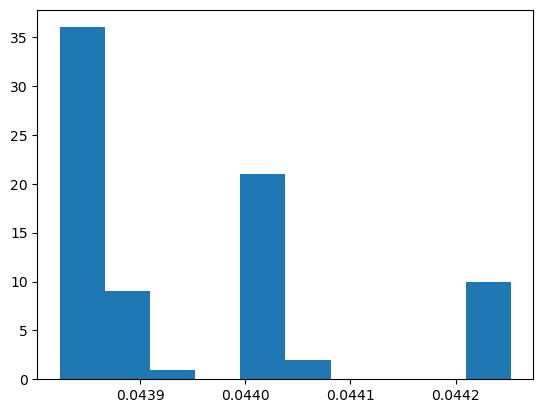

In [5]:
below_thres = pickle.load(open('popoulation_IgEgE_thres05.p', 'rb'))
print(len(below_thres))
params_all = [cos[0] for cos in below_thres]
cost_all = [cos[1] for cos in below_thres]
plt.hist(cost_all)


In [ ]:
# Your data?
values = [16.87, 16.58, 16.56, 16.39, 16.09, 15.98, 16.01, 15.84, 15.98, 
          16.38, 16.04, 16.01, 16.27, 16.52, 16.66, 16.7, 16.91, 17.1, 
          17.31, 17.69, 19.05, 18.71]

Eg_ratio_fe = xr.DataArray(values, dims = ["year"], coords = {"year": np.arange(2000, 2022)})

<xarray.Dataset> Size: 352B
Dimensions:      (year: 22)
Coordinates:
  * year         (year) int64 176B 2000 2001 2002 2003 ... 2018 2019 2020 2021
Data variables:
    Eg_ratio_fe  (year) float64 176B 0.1687 0.1658 0.1656 ... 0.1905 0.1871


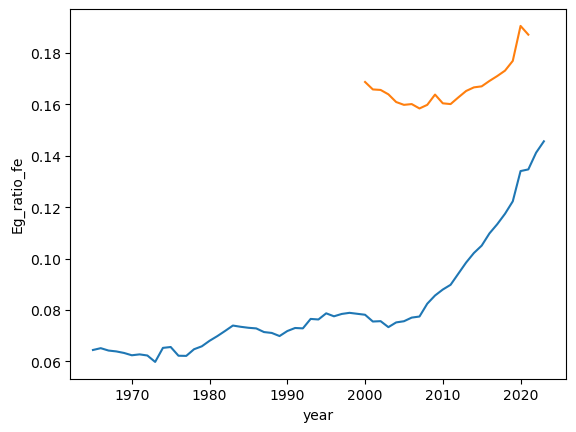

In [13]:
obs['Eg_ratio'].plot()
ds['Eg_ratio_fe'].plot()

In [11]:
parnames

['growth', 'beta_0', 'r_inv', 'a', 'b', 'eta_g', 'eta_f']

In [6]:
year_ini = 2000

params = lef.default_params.copy()

resu_all = []
for parvals in params_all:
    for par, pval in zip(parnames, parvals):
        params[par] = pval

    resu_x = lef.run_model(inicond = inicond, params = params, n_iter = 100, verbose = False, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen)
    resu_all.append(resu_x)

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

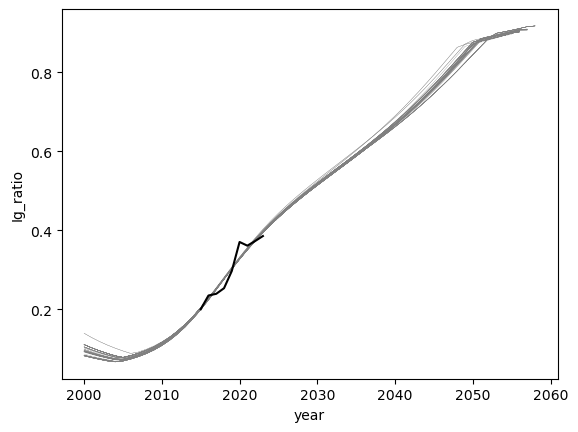

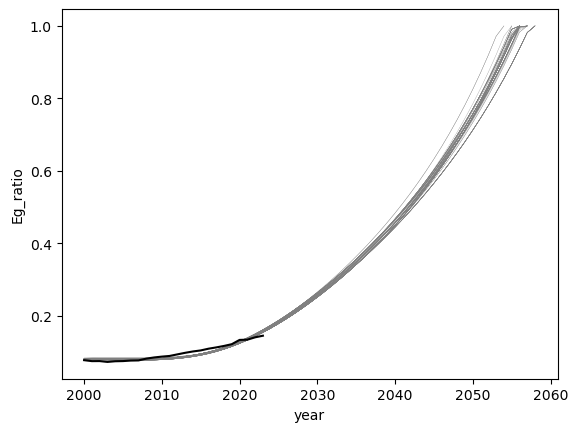

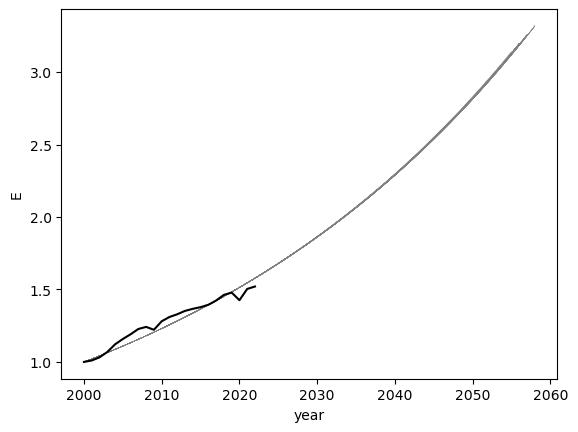

In [7]:
lef.plot_resuvsobs_ds(resu_all, obs, year_ok = slice(2000, 2100), greystyle=True)#, colors = colors)

In [14]:
import plotdigitizer

ModuleNotFoundError: No module named 'plotdigitizer'

### AAAA primary energy -> final energy

https://ourworldindata.org/energy-substitution-method

In [106]:
inicond

{'Y_ini': 1,
 'Eg_ini': array(0.1687),
 'Ef_ini': np.float64(0.8312999999999999),
 'Kf_ini': np.float64(3.8384876428696026),
 'Kg_ini': np.float64(0.4425321223111389)}

169


(array([77., 64.,  0.,  0.,  0.,  0., 22.,  0.,  0.,  6.]),
 array([0.01810893, 0.01819757, 0.01828622, 0.01837487, 0.01846352,
        0.01855216, 0.01864081, 0.01872946, 0.0188181 , 0.01890675,
        0.0189954 ]),
 <BarContainer object of 10 artists>)

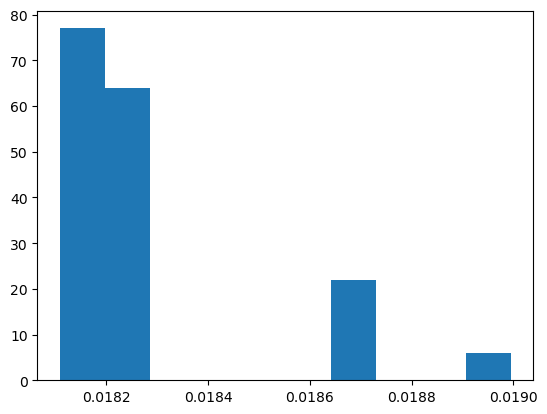

In [107]:
below_thres = pickle.load(open('popoulation_IgEgE_thres05_finalenergy.p', 'rb'))
# below_thres = pickle.load(open('popoulation_IgEgE_thres05_finalenergy_beta0neg.p', 'rb'))
print(len(below_thres))
params_all = [cos[0] for cos in below_thres]
cost_all = [cos[1] for cos in below_thres]
plt.hist(cost_all)

In [111]:
parnames = ['growth', 'beta_0', 'r_inv', 'a', 'b', 'gamma_g', 'eta_g', 'eta_f']

In [92]:
params_all[0]

array([0.02004622, 0.23430056, 0.46872375, 0.21100565, 0.75816988,
       0.80065317, 0.38365531, 0.5241363 ])

In [108]:
year_ini = 2000

params = lef.default_params.copy()
params['a'] = 1
params['b'] = 0.35

inicond_0 = lef.inicond_yr(year_ini)

resu_all = []
params_dict = []
for parvals in params_all:
    for par, pval in zip(parnames, parvals):
        params[par] = pval

    params_dict.append(params.copy())
    inicond = lef.define_K_ini(inicond_0, params)

    resu_x = lef.run_model(inicond = inicond, params = params, n_iter = 100, verbose = False, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen)
    resu_all.append(resu_x)

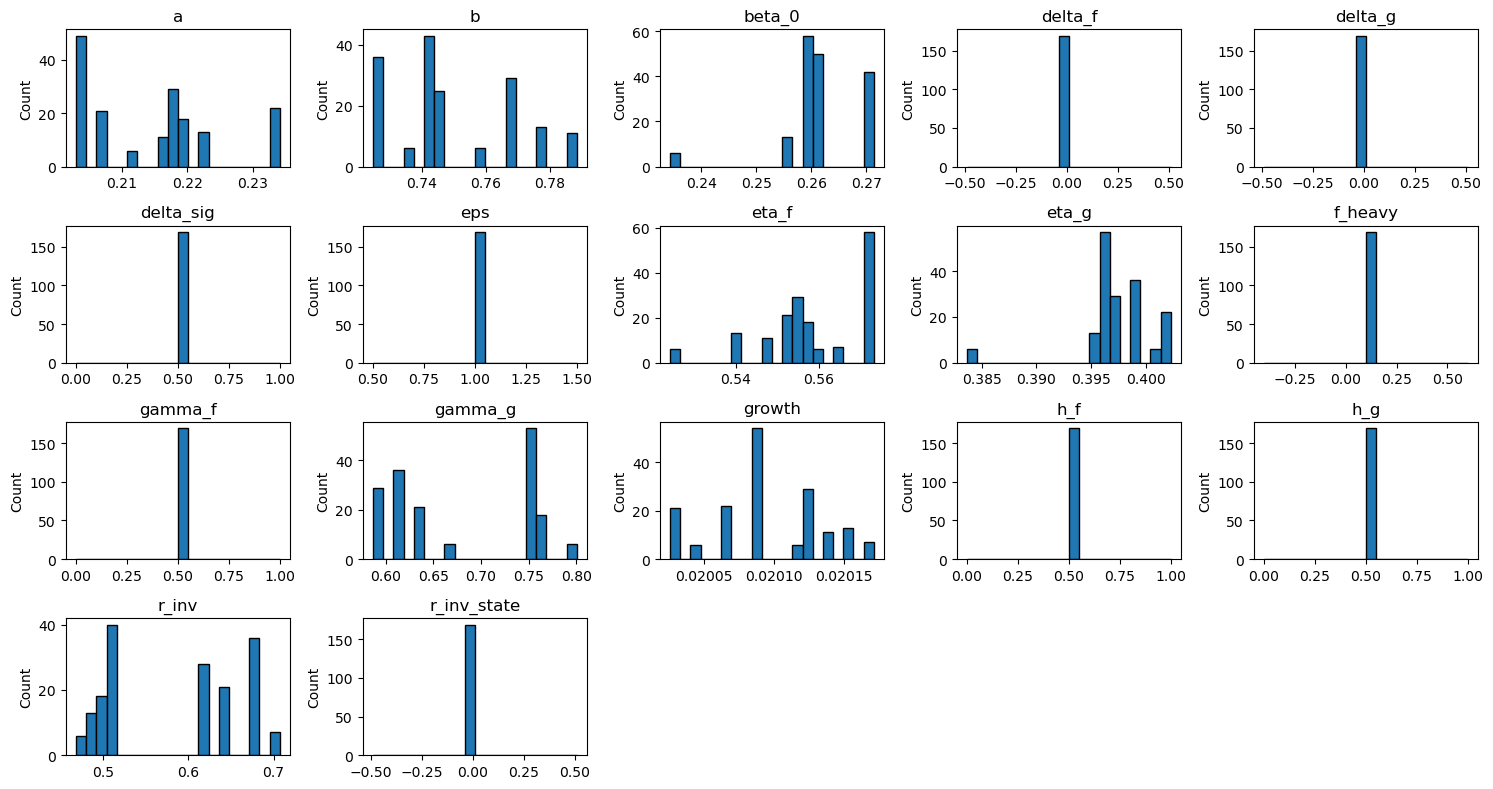

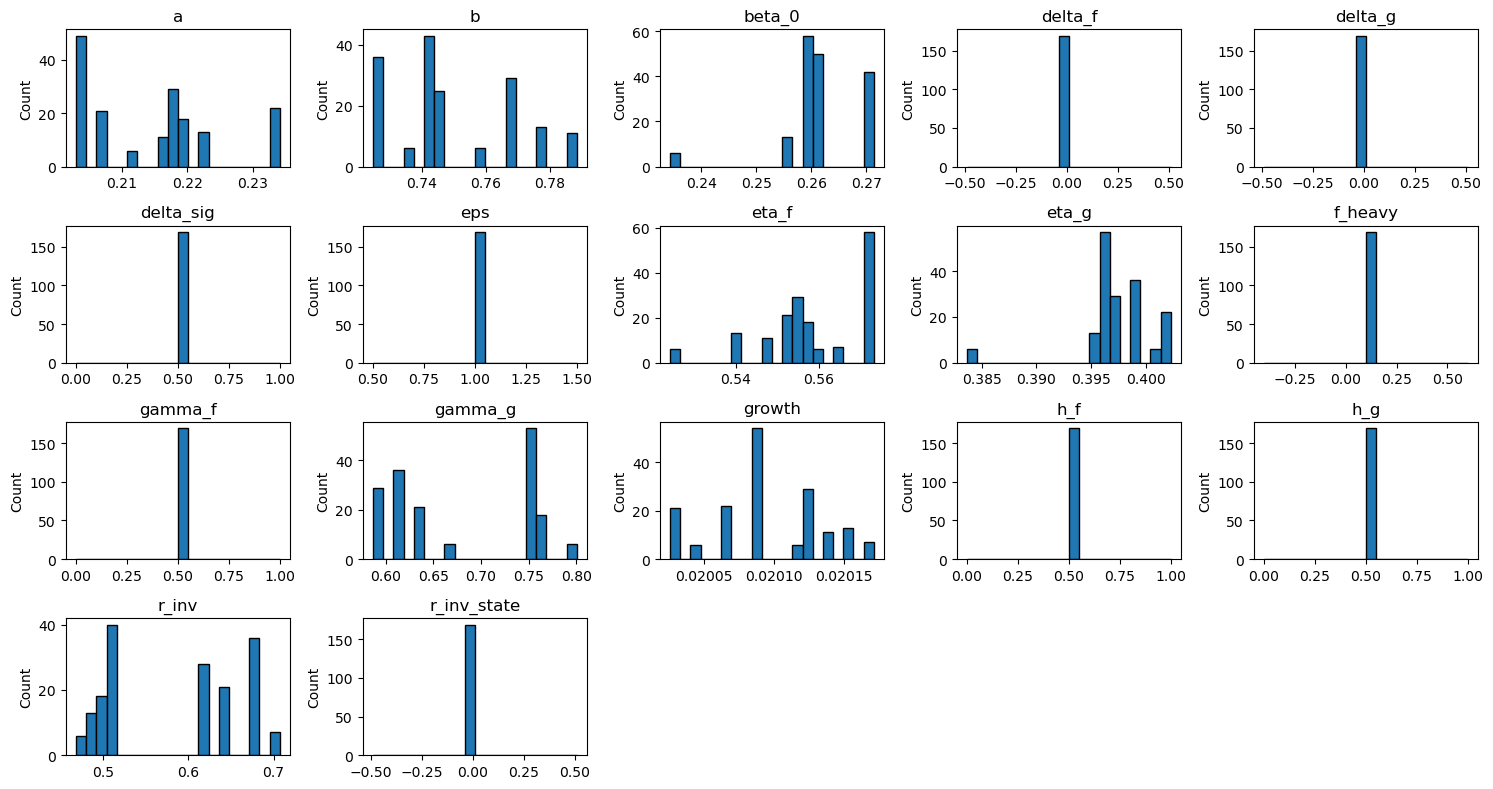

In [109]:
lef.plot_param_histograms(params_dict)

In [ ]:
year_ini = 2000

params = lef.default_params.copy()
params['a'] = 1
params['b'] = 0.35

inicond_0 = lef.inicond_yr(year_ini)

resu_all_beta0 = []
#params_dict = []
for parvals in params_all:
    for par, pval in zip(parnames, parvals):
        params[par] = pval

    #params_dict.append(params.copy())
    params['beta0']
    inicond = lef.define_K_ini(inicond_0, params)

    resu_x = lef.run_model(inicond = inicond, params = params, n_iter = 100, verbose = False, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen)
    resu_all.append(resu_x)

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

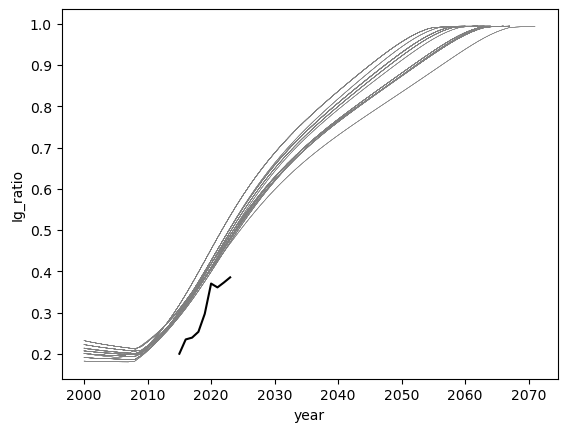

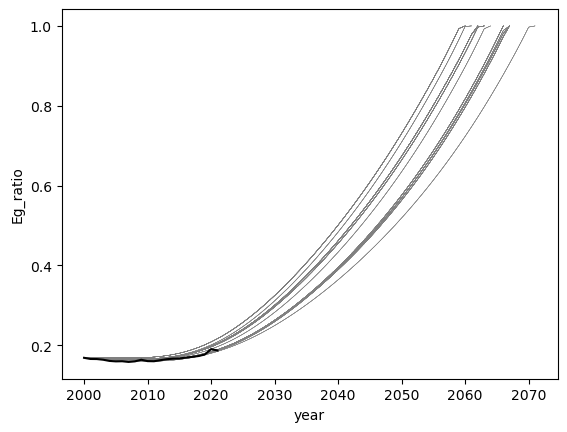

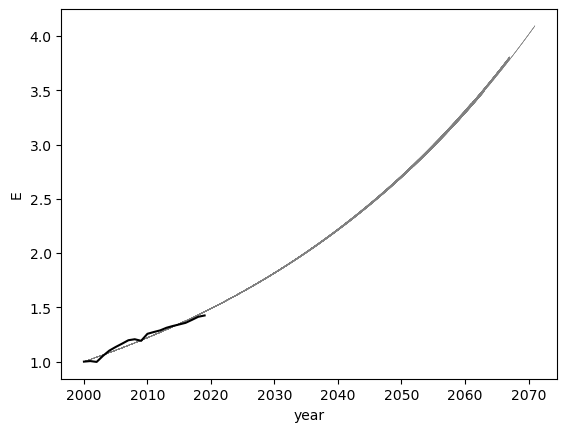

In [110]:
lef.plot_resuvsobs_ds(resu_all, obs, year_ok = slice(2000, 2100), greystyle=True)#, colors = colors)

In [123]:
parvals = [0.02013615, 0.09177662, 0.29297412, 0.35333441, 0.2324367,  0.38868222, 0.2214807]

In [125]:
params = lef.default_params.copy()

for par, pval in zip(parnames, parvals):
    params[par] = pval  

params['a'] = 0.76
params['b'] = 1.07
    #params_dict.append(params.copy())
inicond = lef.define_K_ini(inicond_0, params)

resu_x = lef.run_model(inicond = inicond, params = params, n_iter = 100, verbose = False, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen)

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

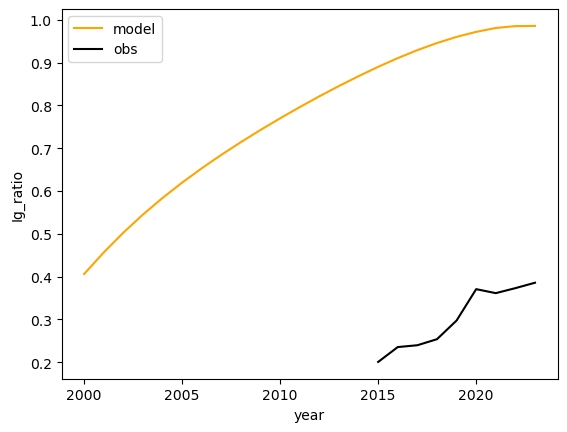

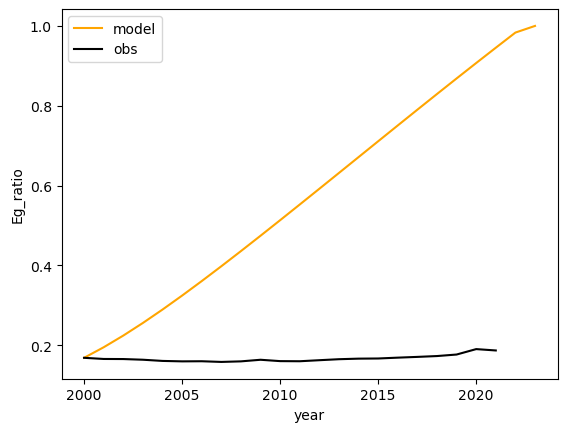

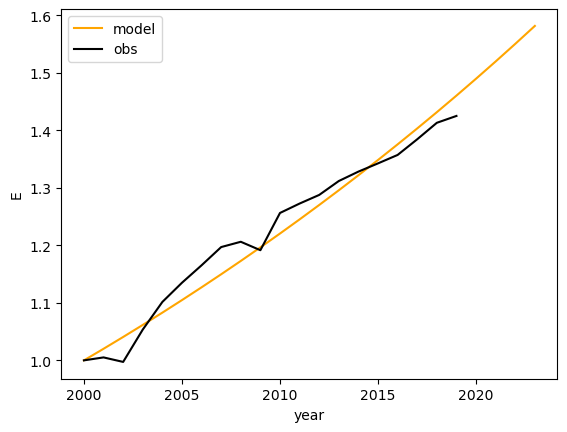

In [126]:
lef.plot_resuvsobs_ds(resu_x, obs, year_ok = slice(2000, 2100))#, greystyle=True)#, colors = colors)

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

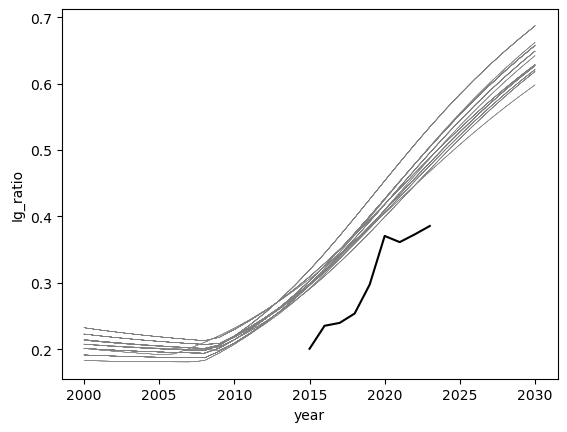

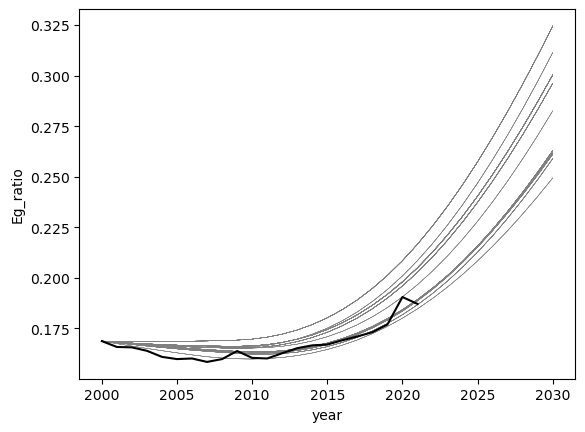

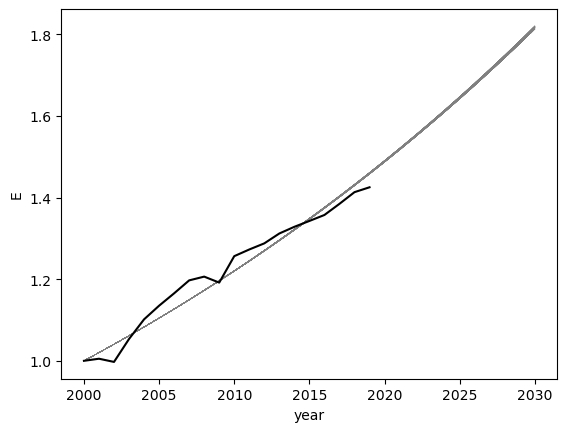

In [95]:
lef.plot_resuvsobs_ds(resu_all, obs, year_ok = slice(2000, 2030), greystyle=True)#, colors = colors)

In [43]:
from importlib import reload
reload(lef)

<module 'lib_ecofun' from '/home/fabiano/Research/git/ecodyn/lib_ecofun.py'>

In [50]:
lef.inicond_yr(2000)

{'Y_ini': 1, 'Eg_ini': array(0.1687), 'Ef_ini': np.float64(0.8312999999999999)}

In [37]:
lef.final_energy_yr(2010).sel(year = 2010)

<xarray.DataArray ()> Size: 8B
array(1.)
Coordinates:
    year     int64 8B 2010

In [57]:
obs_weights = {'Eg_ratio': 10, 'E': 1, 'Ig_ratio':1}

In [59]:
params

{'growth': np.float64(0.01404159120998965),
 'eps': 1,
 'a': 1,
 'b': 0.35,
 'gamma_f': np.float64(0.11874274643435712),
 'gamma_g': np.float64(0.2131635327873307),
 'eta_g': np.float64(0.3712694616778347),
 'eta_f': np.float64(0.3687332120118104),
 'h_g': 0.5,
 'h_f': 0.5,
 'r_inv': np.float64(0.4683678669991325),
 'beta_0': np.float64(-0.4998854361529227),
 'delta_sig': 0.5,
 'delta_g': 0.01,
 'delta_f': 0.01,
 'f_heavy': 0.1,
 'r_inv_state': 0.01}

In [60]:
parnames = ['growth', 'beta_0', 'r_inv', 'gamma_f', 'gamma_g', 'eta_g', 'eta_f']
bounds = [(0.01, 0.03), (-0.5, 0.5), (0.2, 0.9), (0.1, 1.5), (0.1, 1.5), (0.2, 0.9), (0.2, 0.9)]

initial_guess = [lef.best_params[par] for par in parnames]

param_bounds = {par: boun for par, boun in zip(parnames, bounds)}

In [61]:
model_args = (parnames, params, year_ini, inicond, verbose, obs, public_investment, mu_scen, None, obs_weights, param_bounds)

In [66]:
import emcee

threshold = 0.05

def log_prob(x, args):
    cost = lef.cost_function(x, *args)
    return 0 if cost < threshold else -np.inf


In [ ]:
nwalkers = 10
ndim = len(parnames)

In [71]:
initial_guess = np.array(initial_guess)

In [72]:
initial_guess

array([ 0.0209418 , -0.28310971,  0.11684169,  0.5       ,  0.5       ,
        0.2       ,  0.2       ])

In [76]:
sampler.run_mcmc?

Signature: sampler.run_mcmc(initial_state, nsteps, **kwargs)
Docstring:
Iterate :func:`sample` for ``nsteps`` iterations and return the result

Args:
    initial_state: The initial state or position vector. Can also be
        ``None`` to resume from where :func:``run_mcmc`` left off the
        last time it executed.
    nsteps: The number of steps to run.

Other parameters are directly passed to :func:`sample`.

This method returns the most recent result from :func:`sample`.
File:      ~/miniforge3/envs/climtools/lib/python3.13/site-packages/emcee/ensemble.py
Type:      method

In [82]:
# Initialize walkers randomly in bounds
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob)
sampler.run_mcmc(nwalkers*[initial_guess], 1000)
samples = sampler.get_chain(flat=True)

ValueError: Initial state has a large condition number. Make sure that your walkers are linearly independent for the best performance

In [115]:
obs['Eg_ratio'].sel(year = 2000)

<xarray.DataArray ()> Size: 8B
array(0.1687)
Coordinates:
    year     int64 8B 2000

a' e b'

In [118]:
a_primo_final = 0.17+(6/8.5)*(1-0.17)
print(a_primo_final)

0.7558823529411766


In [121]:
b_primo_final = (8.5/6)*a_primo_final
print(b_primo_final)

1.0708333333333335


In [119]:
a_primo_useful = 0.17+(4.6/3.5)*(1-0.17)
print(a_primo_useful)

1.2608571428571427


In [122]:
b_primo_useful = (3.5/4.6)*a_primo_useful
print(b_primo_useful)

0.9593478260869565
